In [1]:
""" BLOCK 1 — Setup """
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patheffects as path_effects
from adjustText import adjust_text
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
import umap

# Set global font sizes and PDF compatibility
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', size=12)          # controls default text sizes
plt.rc('axes', labelsize=12)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=10)    # fontsize of the tick labels
plt.rc('ytick', labelsize=10)    # fontsize of the tick labels
plt.rc('legend', fontsize=10)    # legend fontsize

os.makedirs("../figures", exist_ok=True)

In [2]:
""" BLOCK 2 — Load & Aggregate Data to NATION Level """
df_raw = pd.read_csv("../data/WVS_Cross-National_Wave_7_csv_v6_0.csv", low_memory=False)
df = df_raw.groupby("B_COUNTRY").first().reset_index()

In [3]:
""" BLOCK 3 — THEORY: Objective Variable Selection """
order_vars = ["ruleoflaw", "btistate", "v2x_rule", "corrupttransp"]
liberty_vars = ["v2xcl_rol", "v2x_freexp_altinf", "v2x_frassoc_thick", "v2clrelig"]
equality_vars = ["v2pepwrses", "v2xeg_eqdr", "v2peapsecon", "v2peedueq", "v2pehealth"]
outcome_vars = ["hdi", "GDPpercap1"] 

cols = order_vars + liberty_vars + equality_vars + outcome_vars
data = df[cols].copy()

# Fix GDP strings (e.g. "50,000" -> 50000)
if data["GDPpercap1"].dtype == 'O':
    data["GDPpercap1"] = data["GDPpercap1"].str.replace(',', '').astype(float)

# Replace missing codes
data = data.replace([-5, -4, -3, -2, -1, -9999], np.nan)

In [4]:
""" BLOCK 4 — Data Rescue: KNN Imputation """
# Instead of dropping countries with 1 missing variable, we mathematically estimate it
imputer = KNNImputer(n_neighbors=5)
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns, index=df["B_COUNTRY"])

print("Rescued Macro shape (Countries):", data_imputed.shape)

Rescued Macro shape (Countries): (66, 15)


In [5]:
""" BLOCK 5 — Standardization (Updated names) """
features = order_vars + liberty_vars + equality_vars
scaler = StandardScaler()
scaled_features = pd.DataFrame(
    scaler.fit_transform(data_imputed[features]), 
    columns=features, 
    index=data_imputed.index
)

In [6]:
""" BLOCK 6 — THEORY: Construct Latent Axes (Updated names) """
X_theory = pd.DataFrame({
    "Order": scaled_features[order_vars].mean(axis=1),
    "Liberty": scaled_features[liberty_vars].mean(axis=1),
    "Equality": scaled_features[equality_vars].mean(axis=1)
}, index=data_imputed.index)

# Magnitude and Imbalance remain the same (Geometry logic)
X_theory["Magnitude"] = X_theory[["Order", "Liberty", "Equality"]].mean(axis=1)
X_theory["Imbalance"] = X_theory[["Order", "Liberty", "Equality"]].std(axis=1)

In [7]:
""" BLOCK 7 — DATA-DRIVEN: PCA on Raw Items """
pca_items = PCA(n_components=0.90)
X_items_pca = pca_items.fit_transform(scaled_features)
print("Components needed for 90% variance:", pca_items.n_components_)

Components needed for 90% variance: 5


In [8]:
""" BLOCK 7B — ROBUSTNESS: Unconstrained PCA (Letting the Data Speak) """
# Run a 3-component PCA directly on the 13 raw standardized variables
pca_raw = PCA(n_components=3, random_state=42)
X_raw_pca = pca_raw.fit_transform(scaled_features)

# Create a DataFrame of the loadings to see how variables naturally group
raw_loadings = pd.DataFrame(
    pca_raw.components_.T,
    columns=["Latent_1", "Latent_2", "Latent_3"],
    index=features
)

print("\n--- Unconstrained 3-Component PCA: Variable Groupings ---")
# For easy reading, find which latent dimension each variable naturally maps to
natural_groupings = raw_loadings.abs().idxmax(axis=1)

print("\nVariables that naturally grouped into Latent Dimension 1:")
print(natural_groupings[natural_groupings == "Latent_1"].index.tolist())

print("\nVariables that naturally grouped into Latent Dimension 2:")
print(natural_groupings[natural_groupings == "Latent_2"].index.tolist())

print("\nVariables that naturally grouped into Latent Dimension 3:")
print(natural_groupings[natural_groupings == "Latent_3"].index.tolist())


--- Unconstrained 3-Component PCA: Variable Groupings ---

Variables that naturally grouped into Latent Dimension 1:
['ruleoflaw', 'v2x_rule', 'v2xcl_rol', 'v2peapsecon', 'v2pehealth']

Variables that naturally grouped into Latent Dimension 2:
['v2x_freexp_altinf', 'v2x_frassoc_thick', 'v2clrelig', 'v2xeg_eqdr', 'v2peedueq']

Variables that naturally grouped into Latent Dimension 3:
['btistate', 'corrupttransp', 'v2pepwrses']


In [9]:
""" BLOCK 8 — THEORY PCA (Geometry Check) """
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_theory[["Order", "Liberty", "Equality"]])
print("Explained variance (theory PCA):", pca.explained_variance_ratio_)

Explained variance (theory PCA): [0.8141977 0.1343774 0.0514249]


In [10]:
""" BLOCK 9 — Loadings (Renamed Columns) """
loadings = pd.DataFrame(
    pca.components_,
    columns=["Order", "Liberty", "Equality"],
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print("Theoretical Axis Loadings:\n", loadings)

Theoretical Axis Loadings:
         Order   Liberty  Equality
PC1 -0.607225 -0.546247 -0.576967
PC2  0.146828 -0.790816  0.594181
PC3 -0.780845  0.276087  0.560408


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


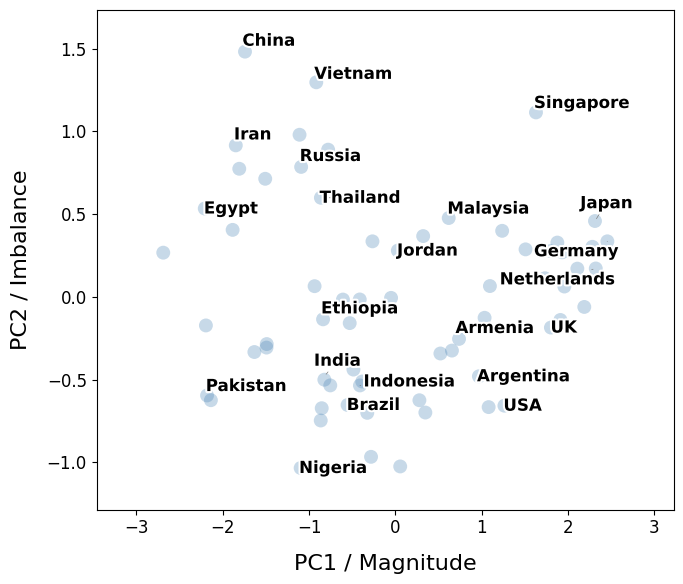

In [39]:
""" BLOCK 10 — H1: Manifold of State Governance (PCA) """
# Define anchor countries (ISO codes)
anchors = {
    702: "Singapore", 528: "Netherlands", 840: "USA", 752: "Sweden",
    276: "Germany", 826: "UK", 392: "Japan", 250: "France",
    643: "Russia", 458: "Malaysia", 156: "China", 32: "Argentina",
    764: "Thailand", 51: "Armenia", 76: "Brazil", 360: "Indonesia",
    400: "Jordan", 364: "Iran", 818: "Egypt", 586: "Pakistan",
    704: "Vietnam", 356: "India", 566: "Nigeria", 231: "Ethiopia"
}

# Coordinate prep
x_vals = X_pca[:, 0] * -1   # Flip PC1 for intuitive 'Right = High Magnitude'
y_vals = X_pca[:, 1]
codes = data_imputed.index.values.astype(int)

plt.figure(figsize=(7, 6))
plt.scatter(x_vals, y_vals, alpha=0.3, s=100, c='steelblue', edgecolors='none')

texts = []
for i, code in enumerate(codes):
    if code in anchors:
        x, y = x_vals[i], y_vals[i]
        if code == 356: 
            y += 0.02
        t = plt.text(x, y, anchors[code], fontsize=12, weight='bold', color='black')
        t.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])
        texts.append(t)

# Solve label collisions
adjust_text(texts, force_text=(0.6, 0.6), arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Styling and Labels
plt.xlabel("PC1 / Magnitude", fontsize=16, labelpad=12)
plt.ylabel("PC2 / Imbalance", fontsize=16, labelpad=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.margins(x=0.15, y=0.10)
plt.tight_layout()

plt.savefig("../figures/fig1_pca_manifold.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig1_pca_manifold.eps", bbox_inches='tight')
plt.show()

/home/adriel/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


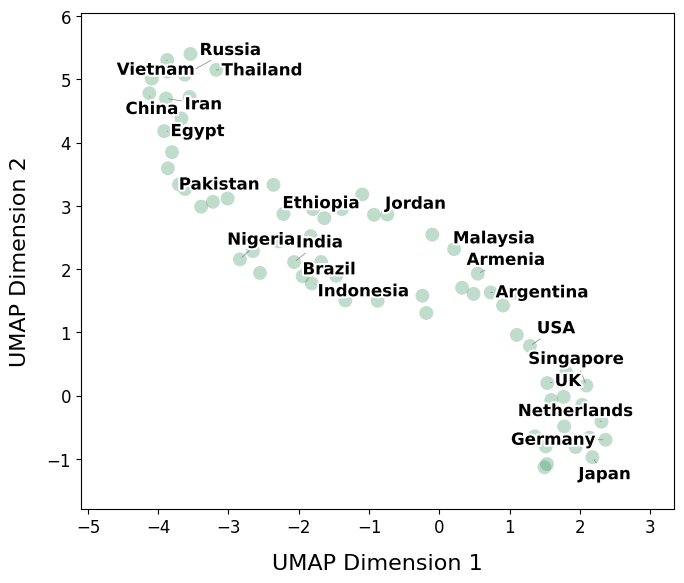

In [40]:
""" BLOCK 11 — H1: UMAP Topological Projection """
import umap
from sklearn.preprocessing import StandardScaler
from adjustText import adjust_text
import matplotlib.patheffects as path_effects

# Use the already consolidated triad from Block 6
X_triad = X_theory[["Order", "Liberty", "Equality"]]
X_scaled_umap = StandardScaler().fit_transform(X_triad)

# Run non-linear manifold reduction
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, init='pca', random_state=42)
embedding = reducer.fit_transform(X_scaled_umap)

# Align orientation with USA on the right
codes = data_imputed.index.values.astype(int)
usa_idx = np.where(codes == 840)[0][0]
if embedding[usa_idx, 0] < 0:
    embedding[:, 0] *= -1

u_x, u_y = embedding[:, 0], embedding[:, 1]

# Plot results
plt.figure(figsize=(7, 6))
plt.scatter(u_x, u_y, alpha=0.3, s=100, c='seagreen', edgecolors='none')

# Add country labels
texts = []
for i, code in enumerate(codes):
    if code in anchors:
        y_pos = u_y[i]
        t = plt.text(u_x[i], y_pos, anchors[code], fontsize=12, weight='bold')
        t.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])
        texts.append(t)

# Solve text collisions
adjust_text(texts, force_text=(0.6, 0.6), arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Set formal labels
plt.xlabel("UMAP Dimension 1", fontsize=16, labelpad=12)
plt.ylabel("UMAP Dimension 2", fontsize=16, labelpad=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.margins(x=0.15, y=0.10)
plt.tight_layout()

# Save figure
plt.savefig("../figures/fig3_umap_projection.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig3_umap_projection.eps", bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


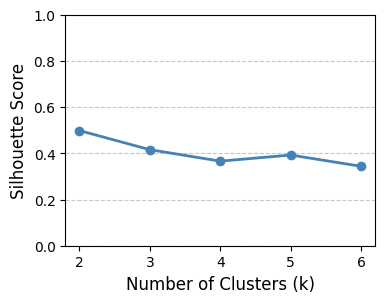

In [29]:
""" BLOCK 12 — H1: Clustering Test """
scores = []

# Calculate silhouette scores to test for natural regime clusters
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(4, 3))
plt.plot(range(2, 7), scores, marker='o', color='steelblue', linewidth=2)

# Professional labeling and scaling
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(range(2, 7))
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure
plt.savefig("../figures/fig4_silhouette_scores.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig4_silhouette_scores.eps", bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


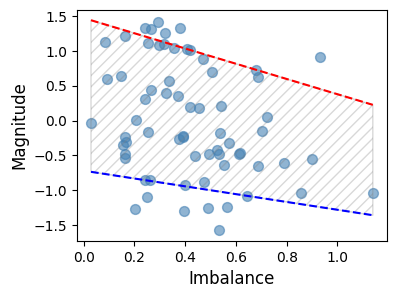

In [30]:
""" BLOCK 13 — H2: The Funnel of State Development (Quantile Constraints)"""
q_data = pd.DataFrame({'Imbalance': X_theory["Imbalance"], 'Magnitude': X_theory["Magnitude"]})
mod = smf.quantreg('Magnitude ~ Imbalance', q_data)
x_vals = np.linspace(q_data['Imbalance'].min(), q_data['Imbalance'].max(), 100)
df_pred = pd.DataFrame({'Imbalance': x_vals})
y_upper = mod.fit(q=0.90).predict(df_pred)
y_lower = mod.fit(q=0.10).predict(df_pred)

plt.figure(figsize=(4, 3))
plt.scatter(X_theory["Imbalance"], X_theory["Magnitude"], alpha=0.6, s=50, c='steelblue')
plt.plot(x_vals, y_upper, color='red', linestyle='--', linewidth=1.5)
plt.plot(x_vals, y_lower, color='blue', linestyle='--', linewidth=1.5)

plt.fill_between(x_vals, y_lower, y_upper, facecolor="none", edgecolor="gray", hatch='///', alpha=0.3)
plt.xlabel("Imbalance")
plt.ylabel("Magnitude")

# Save figure
plt.savefig("../figures/fig5_funnel_capacity.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig5_funnel_capacity.eps", bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


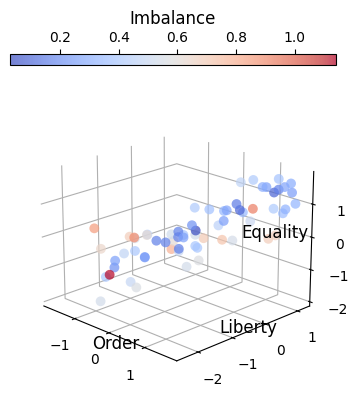

In [21]:
""" BLOCK 14 — H2: The 3D Institutional Manifold """
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

# Map the raw triad with imbalance as the color dimension
scatter = ax.scatter(X_theory['Order'], X_theory['Liberty'], X_theory['Equality'], 
                    c=X_theory['Imbalance'], cmap='coolwarm', s=50, alpha=0.7, edgecolors='none')

# Set blank labels to allow for manual text placement
ax.set_xlabel(''); ax.set_ylabel(''); ax.set_zlabel('')

# Position dimension labels at the extremes of the manifold
ax.text(0.1, -2.5, -2.6, "Order", color='black', fontsize=12, ha='center')
ax.text(1.4, 0, -2.6, "Liberty", color='black', fontsize=12, ha='center')
ax.text(2.5, -1.5, 1.4, "Equality", color='black', fontsize=12, va='center', rotation=90)

# Standardize axis ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.zaxis.set_major_locator(ticker.MultipleLocator(1))

# Clean background panels
ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('w'); ax.yaxis.pane.set_edgecolor('w'); ax.zaxis.pane.set_edgecolor('w')

# Set the perspective to emphasize the "Narrow Corridor" diagonal
ax.view_init(elev=20, azim=-45)
ax.dist = 11

# Add horizontal colorbar for Imbalance visualization
cb = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    location='top', pad=0.08, shrink=0.7, aspect=30)
cb.set_label('Imbalance', fontsize=12, labelpad=5)

# Save figure
plt.savefig("../figures/fig2_3d_manifold.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig2_3d_manifold.eps", bbox_inches='tight')
plt.show()

In [22]:
""" BLOCK 15 — OUTCOMES: Prepare Regression Data """
# Re-attach outcomes
df_model = pd.concat([X_theory, data_imputed[outcome_vars]], axis=1)

# Ensure no negative GDP for logging
df_model = df_model[df_model["GDPpercap1"] > 0]
y_hdi = df_model["hdi"]
y_gdp = np.log(df_model["GDPpercap1"])

# We test our geometry directly against the outcomes to avoid multicollinearity
X_outcomes = sm.add_constant(df_model[["Magnitude", "Imbalance"]])

In [23]:
""" BLOCK 16 — H4: Predicting Human Development (HDI) """
model_hdi = sm.OLS(y_hdi, X_outcomes).fit()
print("\n--- Predictors of Human Development Index (HDI) ---")
print(model_hdi.summary())


--- Predictors of Human Development Index (HDI) ---
                            OLS Regression Results                            
Dep. Variable:                    hdi   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     67.77
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           5.18e-16
Time:                        20:57:33   Log-Likelihood:                 83.285
No. Observations:                  62   AIC:                            -160.6
Df Residuals:                      59   BIC:                            -154.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [24]:
""" BLOCK 17 — H3 & H4: Predicting Economic Prosperity (Log GDP) """
# Note: df_model already has filtered GDP > 0 from Block 15
y_gdp = np.log(df_model["GDPpercap1"].astype(float))

# Predict using the geometric coordinates
X_outcomes = sm.add_constant(df_model[["Magnitude", "Imbalance"]].astype(float))
model_gdp = sm.OLS(y_gdp, X_outcomes).fit()

print("\n--- Predictors of Economic Prosperity (Log GDP) ---")
print(model_gdp.summary())

# Quick geometric interpretation printout
print("\nGeometric Interpretation:")
print(f"H3 Baseline Check: A 1-unit increase in Magnitude changes Log GDP by {model_gdp.params['Magnitude']:.3f}")
print(f"H4 Penalty Check: A 1-unit increase in Imbalance changes Log GDP by {model_gdp.params['Imbalance']:.3f}")


--- Predictors of Economic Prosperity (Log GDP) ---
                            OLS Regression Results                            
Dep. Variable:             GDPpercap1   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     56.85
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.74e-14
Time:                        20:57:33   Log-Likelihood:                -47.762
No. Observations:                  62   AIC:                             101.5
Df Residuals:                      59   BIC:                             107.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [25]:
""" BLOCK 17B — ROBUSTNESS CHECK: Complete Case Analysis """
# Align the raw data's index with the country codes
data_with_index = data.copy()
data_with_index.index = df["B_COUNTRY"]

# Identify countries that had zero missing values in the original raw dataframe
complete_cases_mask = data_with_index[features + outcome_vars].notna().all(axis=1)
complete_cases = data_with_index[complete_cases_mask].index

# CRITICAL FIX: Only keep the complete cases that ALSO survived the GDP > 0 filter from Block 15
valid_complete_cases = df_model.index.intersection(complete_cases)

# Filter our modeled dataframe to ONLY include these valid, non-imputed countries
df_model_complete = df_model.loc[valid_complete_cases]

print(f"\n--- Running Robustness Check on {len(df_model_complete)} Complete Cases ---")

# Re-run the Log GDP model on the strict subset
y_gdp_cc = np.log(df_model_complete["GDPpercap1"].astype(float))
X_outcomes_cc = sm.add_constant(df_model_complete[["Magnitude", "Imbalance"]].astype(float))
model_gdp_cc = sm.OLS(y_gdp_cc, X_outcomes_cc).fit()

print(model_gdp_cc.summary())


--- Running Robustness Check on 30 Complete Cases ---
                            OLS Regression Results                            
Dep. Variable:             GDPpercap1   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     19.62
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           5.47e-06
Time:                        20:57:34   Log-Likelihood:                -21.916
No. Observations:                  30   AIC:                             49.83
Df Residuals:                      27   BIC:                             54.04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


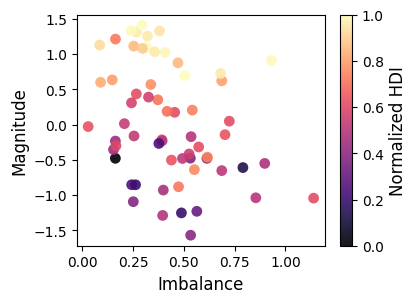

In [26]:
""" BLOCK 18 — Centerpiece Figure: The Geography of HDI """
outcome_norm = (y_hdi - y_hdi.min()) / (y_hdi.max() - y_hdi.min())
plt.figure(figsize=(4, 3))
scatter = plt.scatter(df_model["Imbalance"], df_model["Magnitude"], 
                    c=outcome_norm, cmap='magma', alpha=0.9, s=60, edgecolors='none')
cb = plt.colorbar(scatter)
cb.set_label("Normalized HDI")
plt.xlabel("Imbalance")
plt.ylabel("Magnitude")

# Save figure
plt.savefig("../figures/fig7_hdi_map.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig7_hdi_map.eps", bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


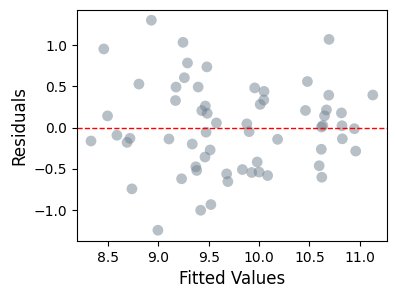

In [27]:
""" BLOCK 19 — OLS Assumption Check """
plt.figure(figsize=(4, 3))

plt.scatter(model_gdp.fittedvalues, model_gdp.resid, alpha=0.5, s=60, edgecolors='none',
            c='slategrey', linewidth=0.5)

# The Zero Line: Red, dashed, slightly thinner for a sharp look
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.xlabel("Fitted Values", fontsize=12)
plt.ylabel("Residuals", fontsize=12)

# Standard tick cleanup
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Save figure
plt.savefig("../figures/fig6_residuals.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig6_residuals.eps", bbox_inches='tight')
plt.show()